   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.1 MB/s eta 0:00:00
Chunk 0: 914 files
Chunk 1: 915 files
Combined total: 1829 files
train=1280 val=274 test=275
Epoch 1/150 - train loss: 1.2817 - lr: 1.00e-04 - elapsed: 1.2 min
Epoch 2/150 - train loss: 0.6958 - lr: 1.00e-04 - elapsed: 2.1 min
  -> Validation Dice: 0.4995
  -> Saved new best model (Dice=0.4995)
Epoch 3/150 - train loss: 0.5773 - lr: 9.99e-05 - elapsed: 3.3 min
Epoch 4/150 - train loss: 0.5186 - lr: 9.98e-05 - elapsed: 4.2 min
  -> Validation Dice: 0.6347
  -> Saved new best model (Dice=0.6347)
Epoch 5/150 - train loss: 0.4892 - lr: 9.97e-05 - elapsed: 5.3 min
Epoch 6/150 - train loss: 0.4716 - lr: 9.96e-05 - elapsed: 6.2 min
  -> Validation Dice: 0.6862
  -> Saved new best model (Dice=0.6862)
Epoch 7/150 - train loss: 0.4590 - lr: 9.95e-05 - elapsed: 7.3 min
Epoch 8/150 - train loss: 0.4524 - lr: 9.93e-05 - elapsed: 8.2 min
  -> Validation Dice: 0.6846
Epoch 9/150 - train loss: 0.4449 - lr: 9.91e-05 - elapsed:

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


Test Dice: 0.7543
Test HD95: 4.0182


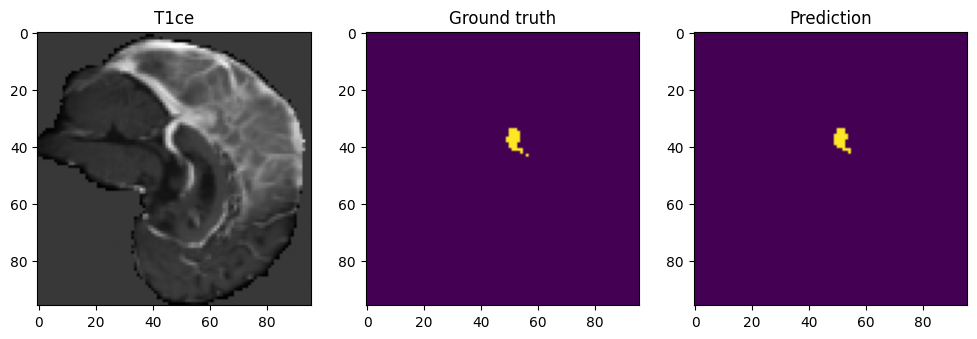

In [1]:
# ============================================================
# BLOCK 1 — Imports
# ============================================================
!pip install -q monai

import os, glob, time, random, warnings
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.data import decollate_batch
from monai.transforms import AsDiscrete
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message=".*ground truth of class.*")
warnings.filterwarnings("ignore", message=".*prediction of class.*")


# ============================================================
# BLOCK 2 — Dataset combining both chunks
# ============================================================
class BraTSPreprocessed(Dataset):
    def __init__(self, files, augment=False):
        self.files = files
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def _augment(self, image, label):
        if random.random() < 0.5:
            axis = random.choice([1, 2, 3])
            image = torch.flip(image, dims=[axis])
            label = torch.flip(label, dims=[axis - 1])
        if random.random() < 0.5:
            k = random.choice([1, 2, 3])
            axes_img = random.choice([(1, 2), (1, 3), (2, 3)])
            axes_lbl = tuple(a - 1 for a in axes_img)
            image = torch.rot90(image, k=k, dims=axes_img)
            label = torch.rot90(label, k=k, dims=axes_lbl)
        if random.random() < 0.2:
            image = image + torch.randn_like(image) * 0.01
        return image, label

    def __getitem__(self, idx):
        d = torch.load(self.files[idx], weights_only=False)
        image = d["image"].float()
        label = d["label"].long()
        if self.augment:
            image, label = self._augment(image, label)
        return image.contiguous(), label.contiguous()


CHUNK_DIRS = [
    "/kaggle/input/datasets/krishybrown/brats2021-ixi-chunk0/processed",
    "/kaggle/input/datasets/krishybrown/brats2021-ixi-chunk1/processed",
]

all_files = []
for i, d in enumerate(CHUNK_DIRS):
    files = sorted(glob.glob(os.path.join(d, "*.pt")))
    print(f"Chunk {i}: {len(files)} files")
    all_files.extend(files)
print(f"Combined total: {len(all_files)} files")
assert len(all_files) > 0, "No files found — check CHUNK_DIRS paths."

n_total = len(all_files)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

random.seed(42)
shuffled = all_files.copy()
random.shuffle(shuffled)
train_files = shuffled[:n_train]
val_files = shuffled[n_train:n_train+n_val]
test_files = shuffled[n_train+n_val:]

train_ds = BraTSPreprocessed(train_files, augment=True)
val_ds   = BraTSPreprocessed(val_files, augment=False)
test_ds  = BraTSPreprocessed(test_files, augment=False)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=2, shuffle=False, num_workers=2, pin_memory=True)
print(f"train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")


# ============================================================
# BLOCK 3 — Model + AMP + LR scheduler
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=3, in_channels=4, out_channels=4,
    channels=(32, 64, 128, 256, 512), strides=(2, 2, 2, 2), num_res_units=2,
).to(device)

loss_fn = DiceCELoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scaler = torch.amp.GradScaler('cuda')

EPOCHS = 150
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

dice_metric = DiceMetric(include_background=False, reduction="mean")
post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)


# ============================================================
# BLOCK 4 — Training loop
# ============================================================
PATIENCE = 15
val_interval = 2
best_val_dice = -1
epochs_no_improve = 0
start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.unsqueeze(1).to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = loss_fn(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()

    scheduler.step()
    epoch_loss /= len(train_loader)
    elapsed = (time.time() - start_time) / 60
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1}/{EPOCHS} - train loss: {epoch_loss:.4f} - lr: {current_lr:.2e} - elapsed: {elapsed:.1f} min")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        dice_metric.reset()
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.unsqueeze(1).to(device)
                with torch.amp.autocast('cuda'):
                    outputs = model(images)
                outputs_list = decollate_batch(outputs)
                labels_list = decollate_batch(labels)
                outputs_conv = [post_pred(o) for o in outputs_list]
                labels_conv = [post_label(l) for l in labels_list]
                dice_metric(y_pred=outputs_conv, y=labels_conv)

        val_dice = dice_metric.aggregate().item()
        dice_metric.reset()
        print(f"  -> Validation Dice: {val_dice:.4f}")

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            epochs_no_improve = 0
            torch.save(model.state_dict(), "/kaggle/working/best_unet3d.pth")
            print(f"  -> Saved new best model (Dice={val_dice:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print("Early stopping triggered.")
                break

print(f"Training finished in {(time.time()-start_time)/60:.1f} min. Best val Dice: {best_val_dice:.4f}")


# ============================================================
# BLOCK 5 — Test evaluation (CPU-forced Hausdorff)
# ============================================================
hausdorff_metric = HausdorffDistanceMetric(include_background=False, percentile=95)

model.load_state_dict(torch.load("/kaggle/working/best_unet3d.pth", weights_only=False))
model.eval()
dice_metric.reset()
hausdorff_metric.reset()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)
        with torch.amp.autocast('cuda'):
            outputs = model(images)
        outputs_list = decollate_batch(outputs)
        labels_list = decollate_batch(labels)
        outputs_conv = [post_pred(o).cpu() for o in outputs_list]
        labels_conv = [post_label(l).cpu() for l in labels_list]
        dice_metric(y_pred=outputs_conv, y=labels_conv)
        hausdorff_metric(y_pred=outputs_conv, y=labels_conv)

test_dice = dice_metric.aggregate().item()
hd_raw = hausdorff_metric.aggregate()
hd_valid = hd_raw[~torch.isnan(hd_raw) & ~torch.isinf(hd_raw)]
test_hd95 = hd_valid.mean().item() if len(hd_valid) > 0 else float('nan')

print(f"Test Dice: {test_dice:.4f}")
print(f"Test HD95: {test_hd95:.4f}" if test_hd95 == test_hd95 else "Test HD95: undefined")


# ============================================================
# BLOCK 6 — Visual check
# ============================================================
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)
with torch.no_grad():
    with torch.amp.autocast('cuda'):
        pred = torch.argmax(model(images), dim=1)[0].cpu().numpy()

slice_idx = pred.shape[0] // 2
gt = labels[0].numpy()

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(images[0, 1, slice_idx].cpu(), cmap="gray"); ax[0].set_title("T1ce")
ax[1].imshow(gt[slice_idx], cmap="viridis"); ax[1].set_title("Ground truth")
ax[2].imshow(pred[slice_idx], cmap="viridis"); ax[2].set_title("Prediction")
plt.show()